# Estimate agricultural land fraction (exposure)

**Do you want to estimate the fraction of agricultural land for your region?**

This short how-to gives you the code you need to create a timeseries of the agricultural land fraction using satellite-based land cover data and save it as a csv file. The final csv file can be used as, e.g., exposure data for the drought risk estimation. 

**Do uou want to see this data in action?** 
We use it in the "quick start" guide as exposure! Take a look 

## Set region and load libraries

In [5]:
import zipfile
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import regionmask
from pathlib import Path

# Create a data directory
data_dir = Path("data")
data_dir.mkdir(exist_ok=True)

In [6]:
# Create regions subdirectory
regions_dir = data_dir / 'regions'
regions_dir.mkdir(exist_ok=True)

# Read NUTS shapefiles
nuts_shp = regions_dir / 'NUTS_RG_20M_2024_4326' / 'NUTS_RG_20M_2024_4326.shp'
nuts_gdf = gpd.read_file(nuts_shp)

In [7]:
admin_id = "EL64"
sel_gdf = nuts_gdf[nuts_gdf['NUTS_ID'] == admin_id]
print(f"Found {admin_id} region: {sel_gdf.geometry.total_bounds}")

Found EL64 region: [21.39637798 37.98898161 24.67199242 39.27219519]


In [9]:
# Define bounding box for admin region 
# Format: [North, West, South, East]
lon_min, lon_max = sel_gdf.geometry.total_bounds[0], sel_gdf.geometry.total_bounds[2]
lat_min, lat_max = sel_gdf.geometry.total_bounds[1], sel_gdf.geometry.total_bounds[3]


## Download Land Cover Data

We'll use a high-resolution land cover dataset to identify agricultural areas within your region, and create a timeseries of the fraction of agricultural land. 

The dataset that we are using here is from Copernicus, and is entitled "Land cover classification gridded maps from 1992 to present derived from satellite observations". The dataset is at 300m spatial resolution. You can find more details here: https://cds.climate.copernicus.eu/datasets/satellite-land-cover?tab=overview

It contains two versions: version 2.0.7cds provides the land cover for the years 1992 – 2015; and version 2.1.1 for the years after 2016. We'll download both versions to create a timeseries. Due to the volume of the dataset, we'll download year by year. 

> ⏱️ **Time needed!** Requesting and downloading this high-resolution data for just one year, even if cut down to the region of interest, takes about ~9 minutes. For all years currently available (1992-2023), the download takes about **4 hours**. 


In [23]:
for yyyy in range(1992, 2023):
    print(f"Year {yyyy}: Downloading land cover data...")

    if yyyy <= 2015:
        lc_version = "v2_0_7cds"
    else:
        lc_version = "v2_1_1"
    dataset = "satellite-land-cover"
    request = {
        "variable": "all",
        "year": [str(yyyy)],
        "version": [lc_version],
        "area": [lat_max, lon_min, lat_min, lon_max]  # [North, West, South, East]
    }

    client = cdsapi.Client()
    client.retrieve(dataset, request).download(str(data_dir / f'land_cover_{admin_id}_{yyyy}.zip'))

print("Land cover download complete!")

Year 1992: Downloading land cover data...


2026-01-29 10:10:43,014 INFO [2025-07-04T00:00:00] Due to a transition between project phases, there are changes to the timeline of this dataset updates, which are usually on an annual basis with a one year delay: 2023 and 2024 data updates are now expected during 2026. Please watch the [forum](https://forum.ecmwf.int/c/announcements/5) for future announcements.
2026-01-29 10:10:43,014 INFO Request ID is 1e034d26-075f-4354-8dc2-d15c4679e62e
2026-01-29 10:10:43,043 INFO status has been updated to accepted
2026-01-29 10:10:52,081 INFO status has been updated to running
2026-01-29 10:19:03,243 INFO status has been updated to successful


bcd457322831e891eafca4475d02ee99.zip:   0%|          | 0.00/714k [00:00<?, ?B/s]

2026-01-29 10:19:03,541 INFO [2025-07-04T00:00:00] Due to a transition between project phases, there are changes to the timeline of this dataset updates, which are usually on an annual basis with a one year delay: 2023 and 2024 data updates are now expected during 2026. Please watch the [forum](https://forum.ecmwf.int/c/announcements/5) for future announcements.
2026-01-29 10:19:03,541 INFO Request ID is fac5b568-79db-4599-85a0-3affd4122d54
2026-01-29 10:19:03,570 INFO status has been updated to accepted


Year 1993: Downloading land cover data...


...

9413ed2ed7fce49b65ea632d05d4b58c.zip:   0%|          | 0.00/714k [00:00<?, ?B/s]

2026-01-29 10:48:20,340 INFO [2025-07-04T00:00:00] Due to a transition between project phases, there are changes to the timeline of this dataset updates, which are usually on an annual basis with a one year delay: 2023 and 2024 data updates are now expected during 2026. Please watch the [forum](https://forum.ecmwf.int/c/announcements/5) for future announcements.
2026-01-29 10:48:20,340 INFO Request ID is 25c343a0-50aa-4228-b9e4-a2ee07d170bf
2026-01-29 10:48:20,352 INFO status has been updated to accepted


Year 1997: Downloading land cover data...


2026-01-29 10:48:42,017 INFO status has been updated to running


KeyboardInterrupt: 

## Create a mask for your region

In [11]:
# Create a regionmask from the admin region geometry
admin_mask = regionmask.from_geopandas(sel_gdf, names='NUTS_ID')

# Inspect one zip file and read the NetCDF file to get a grid for masking
with zipfile.ZipFile(data_dir / f'land_cover_{admin_id}_1992.zip', 'r') as zip_ref:
    # List all files in the zip
    file_list = zip_ref.namelist()
    print(f"Files in land_cover_{admin_id}_1992.zip")
    for f in file_list:
        print(f"  - {f}")
    
    # Find the NetCDF file (typically the largest or with .nc extension)
    nc_files_in_zip = [f for f in file_list if f.endswith('.nc')]
    
    if nc_files_in_zip:
        lc_filename = nc_files_in_zip[0]
        # Extract only this file
        zip_ref.extract(lc_filename, data_dir)
    else:
        print("No NetCDF file found in zip!")

# Load land cover data
lc_file = data_dir / lc_filename
print(f"Using file: {lc_file.name}")
lc_ds = xr.open_dataset(lc_file)

# Subset to our region (initial bounding box)
lc_region = lc_ds.sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_max, lat_min)
)

# Create admin region mask: 1 where EL64 region, 0 elsewhere
# regionmask.mask returns the region index where inside, NaN where outside
lc_admin_mask_raw = admin_mask.mask(lc_region.lon, lc_region.lat)
print(f"\nRaw mask unique values: {np.unique(lc_admin_mask_raw.values[~np.isnan(lc_admin_mask_raw.values)])}")

# Convert to binary: 1 where inside region (not NaN), 0 elsewhere
lc_admin_mask = xr.DataArray(
    (~np.isnan(lc_admin_mask_raw.values)).astype(float),
    coords={'lat': lc_region.lat, 'lon': lc_region.lon},
    dims=['lat', 'lon']
)

print(f"Admin mask unique values: {np.unique(lc_admin_mask.values)}")
print(f"Admin region area (grid cells): {lc_admin_mask.sum().values:.0f}")

Files in land_cover_EL64_1992.zip
  - ESACCI-LC-L4-LCCS-Map-300m-P1Y-1992-v2.0.7cds.area-subset.39.27219519300007.24.671992415000034.37.98898161400007.21.396377976000053.nc
Using file: ESACCI-LC-L4-LCCS-Map-300m-P1Y-1992-v2.0.7cds.area-subset.39.27219519300007.24.671992415000034.37.98898161400007.21.396377976000053.nc


/usr/local/apps/python3/3.12.11-01/lib/python3.12/site-packages/gribapi/__init__.py:23: UserWarning: ecCodes 2.42.0 or higher is recommended. You are running version 2.31.0
  warnings.warn(



Raw mask unique values: [722.]
Admin mask unique values: [0. 1.]
Admin region area (grid cells): 215798


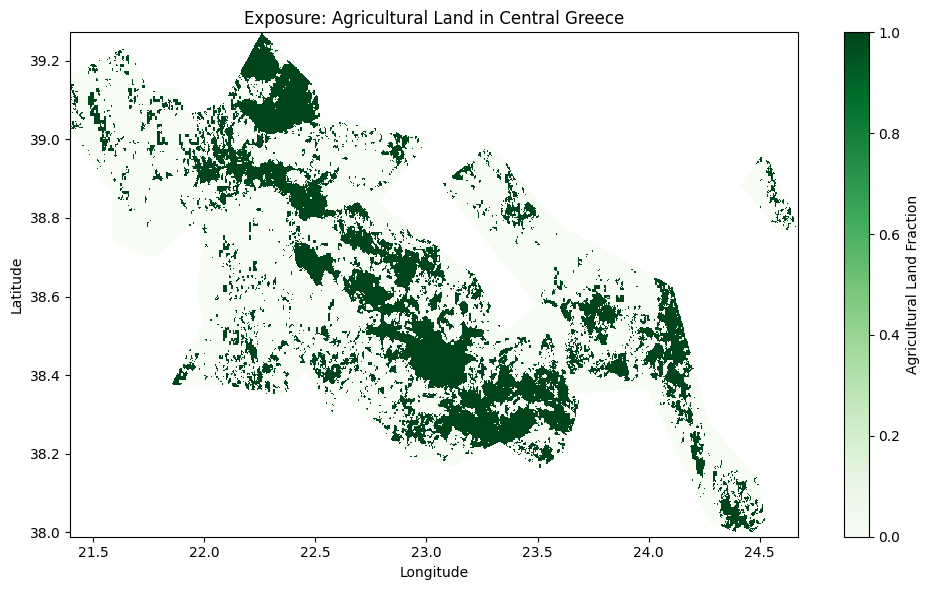

In [ ]:
ag_mask = ((lc_region['lccs_class'] >= 10) & (lc_region['lccs_class'] <= 40)).astype(float)
exposure = ag_mask.where(lc_admin_mask == 1, drop=True)
fig, ax = plt.subplots(figsize=(10, 6))
exposure.plot(ax=ax, cmap='Greens', cbar_kwargs={'label': 'Agricultural Land Fraction'})
ax.set_title(f'Exposure: Agricultural Land in Central Greece (Year 1992)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

## Read annual land cover maps and estimate agricultural land fraction

In [40]:
# Initialize list to store results
ag_data = []

for yyyy in range(1992, 1996):  # Updated to full range

    # Inspect one zip file and read the NetCDF file to get a grid for masking
    with zipfile.ZipFile(data_dir / f'land_cover_{admin_id}_{yyyy}.zip', 'r') as zip_ref:
            
        # List all files in the zip
        file_list = zip_ref.namelist()
        print(f"Files in land_cover_{admin_id}_{yyyy}.zip")
        for f in file_list:
            print(f"  - {f}")
            
        # Find the NetCDF file (typically the largest or with .nc extension)
        nc_files_in_zip = [f for f in file_list if f.endswith('.nc')]
            
        if nc_files_in_zip:
            lc_filename = nc_files_in_zip[0]
            # Extract only this file
            zip_ref.extract(lc_filename, data_dir)
        else:
            print("No NetCDF file found in zip!")

        # Load land cover data
        lc_file = data_dir / lc_filename
        print(f"Using file: {lc_file.name}")
        lc_ds = xr.open_dataset(lc_file)

        # Subset to our region (initial bounding box)
        lc_region = lc_ds.sel(
            lon=slice(lon_min, lon_max),
            lat=slice(lat_max, lat_min)
        )

        # Create agricultural land mask: 1 where agricultural land, 0 elsewhere
        ag_mask = ((lc_region['lccs_class'] >= 10) & (lc_region['lccs_class'] <= 40)).astype(float)

        # Calculate agricultural land fraction: sum(ag_mask * admin_mask) / sum(admin_mask)
        ag_fraction = (ag_mask * lc_admin_mask).sum().values / lc_admin_mask.sum().values

        print(f"Agricultural land coverage in {admin_id} ({yyyy}): {ag_fraction*100:.1f}%")
        
        # Store result
        ag_data.append({'year': yyyy, 'ag_fraction': ag_fraction})

# Create pandas DataFrame and save to CSV
ag_timeseries = pd.DataFrame(ag_data)
ag_timeseries.set_index('year', inplace=True)

# Save to CSV
output_file = data_dir / f'agricultural_land_fraction_{admin_id}.csv'
ag_timeseries.to_csv(output_file)
print(f"\nTimeseries saved to: {output_file}")
print(ag_timeseries)

Files in land_cover_EL64_1992.zip
  - ESACCI-LC-L4-LCCS-Map-300m-P1Y-1992-v2.0.7cds.area-subset.39.27219519300007.24.671992415000034.37.98898161400007.21.396377976000053.nc
Using file: ESACCI-LC-L4-LCCS-Map-300m-P1Y-1992-v2.0.7cds.area-subset.39.27219519300007.24.671992415000034.37.98898161400007.21.396377976000053.nc
Agricultural land coverage in EL64 (1992): 30.5%
Files in land_cover_EL64_1993.zip
  - ESACCI-LC-L4-LCCS-Map-300m-P1Y-1993-v2.0.7cds.area-subset.39.27219519300007.24.671992415000034.37.98898161400007.21.396377976000053.nc
Using file: ESACCI-LC-L4-LCCS-Map-300m-P1Y-1993-v2.0.7cds.area-subset.39.27219519300007.24.671992415000034.37.98898161400007.21.396377976000053.nc
Agricultural land coverage in EL64 (1993): 30.5%
Files in land_cover_EL64_1994.zip
  - ESACCI-LC-L4-LCCS-Map-300m-P1Y-1994-v2.0.7cds.area-subset.39.27219519300007.24.671992415000034.37.98898161400007.21.396377976000053.nc
Using file: ESACCI-LC-L4-LCCS-Map-300m-P1Y-1994-v2.0.7cds.area-subset.39.27219519300007.2

In [42]:
# Read the CSV data
ag_data_df = pd.read_csv(output_file)

# Display the data
print("Agricultural Land Fraction Timeseries:")
print(ag_data_df)
print(f"\nSummary statistics:")
print(ag_data_df['ag_fraction'].describe())

Agricultural Land Fraction Timeseries:
   year  ag_fraction
0  1992     0.304581
1  1993     0.304572
2  1994     0.304567
3  1995     0.301157

Summary statistics:
count    4.000000
mean     0.303719
std      0.001708
min      0.301157
25%      0.303715
50%      0.304570
75%      0.304574
max      0.304581
Name: ag_fraction, dtype: float64


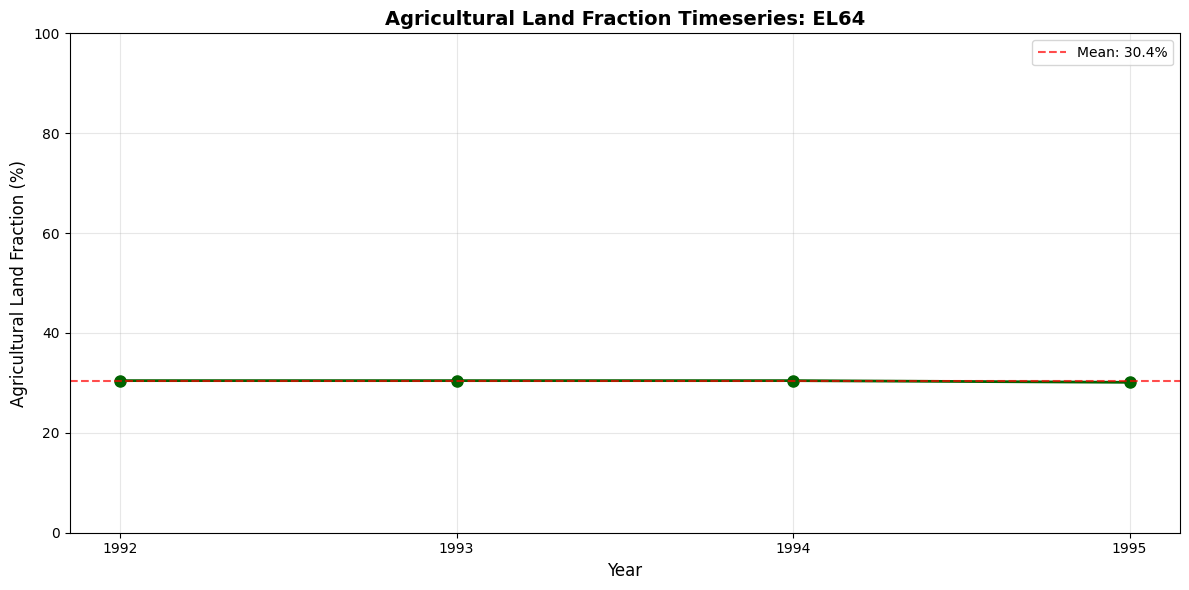


Interpretation:
- Mean agricultural land fraction: 30.4%
- Range: 30.1% to 30.5%
- Change from 1992 to 1995: -0.34 percentage points


In [45]:
# Visualize the agricultural land fraction over time
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the timeseries
ax.plot(ag_data_df['year'], ag_data_df['ag_fraction'] * 100, 
        marker='o', linewidth=2, markersize=8, color='darkgreen')

ax.set_title(f'Agricultural Land Fraction Timeseries: {admin_id}', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Agricultural Land Fraction (%)', fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0, top=100)

# Set x-axis to show only full years
ax.set_xticks(ag_data_df['year'].values)
ax.set_xticklabels(ag_data_df['year'].values.astype(int))

# Add mean line
mean_fraction = ag_data_df['ag_fraction'].mean() * 100
ax.axhline(y=mean_fraction, color='red', linestyle='--', 
           label=f'Mean: {mean_fraction:.1f}%', alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()

# Print interpretation
print(f"\nInterpretation:")
print(f"- Mean agricultural land fraction: {ag_data_df['ag_fraction'].mean()*100:.1f}%")
print(f"- Range: {ag_data_df['ag_fraction'].min()*100:.1f}% to {ag_data_df['ag_fraction'].max()*100:.1f}%")
change = (ag_data_df['ag_fraction'].iloc[-1] - ag_data_df['ag_fraction'].iloc[0]) * 100
print(f"- Change from {ag_data_df['year'].iloc[0]} to {ag_data_df['year'].iloc[-1]}: {change:+.2f} percentage points")

... and just like that, we have a timeseries that shows the percentage of agricultural land in your region of interest. 

## What's next? 
**Do uou want to see this data in action?** 

We use it in the "quick start" guide as exposure and to estimate drought risk! Take a look: 
- [Get started tutorial](../tutorials/get_started.ipynb)